In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('deu.txt', sep='\t', header=None, names=['english', 'german', 'attribution'])

In [ ]:
df.head()

,english,german,attribution
0,Go.,Geh.,CC-BY 2.0 (France) Attribution: tatoeba.org #2...
1,Hi.,Hallo!,CC-BY 2.0 (France) Attribution: tatoeba.org #5...
2,Hi.,Grüß Gott!,CC-BY 2.0 (France) Attribution: tatoeba.org #5...
3,Run!,Lauf!,CC-BY 2.0 (France) Attribution: tatoeba.org #9...
4,Run.,Lauf!,CC-BY 2.0 (France) Attribution: tatoeba.org #4...


In [ ]:
df=df.drop(columns=['attribution'])

In [9]:
df.head()

,english,german
0,Go.,Geh.
1,Hi.,Hallo!
2,Hi.,Grüß Gott!
3,Run!,Lauf!
4,Run.,Lauf!


In [10]:
import re
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespaces
    return text

df['english'] = df['english'].apply(clean_text)
df['german'] = df['german'].apply(clean_text)

In [12]:
df.head(15)

,english,german
0,go,geh
1,hi,hallo
2,hi,grüß gott
3,run,lauf
4,run,lauf
5,wow,potzdonner
6,wow,donnerwetter
7,fire,feuer
8,help,hilfe
9,help,zu hülf


In [17]:
# re-clean german (remove duplicate sos/eos we added earlier)
df['german'] = df['german'].str.replace('<sos> ', '').str.replace(' <eos>', '')

# re-tokenize
df['eng_tokens'] = df['english'].apply(lambda x: x.split())
df['deu_tokens'] = df['german'].apply(lambda x: x.split())

# re-filter
df = df[df['eng_tokens'].apply(len) <= MAX_LEN]
df = df[df['deu_tokens'].apply(len) <= MAX_LEN]

# rebuild vocab (without sos/eos in german sentences)
eng_word2idx, eng_idx2word = build_vocab(df['eng_tokens'])
deu_word2idx, deu_idx2word = build_vocab(df['deu_tokens'])

# encode — add sos/eos only for german during encoding
def encode_eng(tokens, word2idx):
    unk = word2idx['<unk>']
    return [word2idx.get(w, unk) for w in tokens]

def encode_deu(tokens, word2idx):
    unk = word2idx['<unk>']
    return [word2idx['<sos>']] + [word2idx.get(w, unk) for w in tokens] + [word2idx['<eos>']]

df['eng_encoded'] = df['eng_tokens'].apply(lambda x: encode_eng(x, eng_word2idx))
df['deu_encoded'] = df['deu_tokens'].apply(lambda x: encode_deu(x, deu_word2idx))

# pad
eng_padded = pad_sequences(df['eng_encoded'].tolist(), maxlen=MAX_LEN, padding='post', value=eng_word2idx['<pad>'])
deu_padded = pad_sequences(df['deu_encoded'].tolist(), maxlen=MAX_LEN+2, padding='post', value=deu_word2idx['<pad>'])

# train/val split
eng_train, eng_val, deu_train, deu_val = train_test_split(
    eng_padded, deu_padded, test_size=0.1, random_state=42
)

# verify with matching index this time
idx = 42
print("English sentence :", df['english'].iloc[idx])
print("Encoded          :", df['eng_encoded'].iloc[idx])
print()
print("German sentence  :", df['german'].iloc[idx])
print("Encoded          :", df['deu_encoded'].iloc[idx])

English sentence : got it
Encoded          : [34, 30]

German sentence  : verstanden
Encoded          : [1, 51, 2]


In [18]:
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_ENG_LEN = 20
MAX_DEU_LEN = 22  # 20 + <sos> + <eos>

eng_padded = pad_sequences(df['eng_encoded'].tolist(), maxlen=MAX_ENG_LEN, padding='post', value=eng_word2idx['<pad>'])
deu_padded = pad_sequences(df['deu_encoded'].tolist(), maxlen=MAX_DEU_LEN, padding='post', value=deu_word2idx['<pad>'])

eng_train, eng_val, deu_train, deu_val = train_test_split(
    eng_padded, deu_padded, test_size=0.1, random_state=42
)

print(f"Train size: {len(eng_train):,}")
print(f"Val   size: {len(eng_val):,}")

Train size: 198,317
Val   size: 22,036


In [19]:
idx = 42
print("English sentence :", df['english'].iloc[idx])
print("Encoded          :", df['eng_encoded'].iloc[idx])
print("Padded           :", eng_padded[idx])

print()

print("German sentence  :", df['german'].iloc[idx])
print("Encoded          :", df['deu_encoded'].iloc[idx])
print("Padded           :", deu_padded[idx])

English sentence : got it
Encoded          : [34, 30]
Padded           : [34 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

German sentence  : verstanden
Encoded          : [1, 51, 2]
Padded           : [ 1 51  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [21]:
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      AdditiveAttention, Dot, Activation,
                                      Concatenate, TimeDistributed)
from tensorflow.keras.models import Model

# correctly defined variables
en_vocab_size = len(eng_word2idx)
de_vocab_size = len(deu_word2idx)
embedding_dim = 256
lstm_units    = 512
max_enc_len   = MAX_ENG_LEN       # 20
max_dec_len   = MAX_DEU_LEN - 1   # 21 (decoder input is without last <eos>)

def build_model(en_vocab_size, de_vocab_size, embedding_dim, hidden_units, max_enc_len, max_dec_len):
    # ── Encoder ──────────────────────────────────────────────
    encoder_input = Input(shape=(max_enc_len,), name='encoder_input')
    encoder_emb   = Embedding(en_vocab_size, embedding_dim)(encoder_input)
    encoder_lstm  = LSTM(hidden_units, return_sequences=True, return_state=True, dropout=0.3)
    encoder_out, state_h, state_c = encoder_lstm(encoder_emb)
    # encoder_out: (batch, max_enc_len, hidden_units) — needed for Luong attention
    encoder_states = [state_h, state_c]

    # ── Decoder ──────────────────────────────────────────────
    decoder_input = Input(shape=(max_dec_len,), name='decoder_input')
    decoder_emb   = Embedding(de_vocab_size, embedding_dim)(decoder_input)
    decoder_lstm  = LSTM(hidden_units, return_sequences=True, return_state=True, dropout=0.3)
    decoder_out, _, _ = decoder_lstm(decoder_emb, initial_state=encoder_states)
    # decoder_out: (batch, max_dec_len, hidden_units)

    # ── Luong Attention (dot product) ────────────────────────
    # score = decoder_out · encoder_out^T
    attention_scores = Dot(axes=[2, 2])([decoder_out, encoder_out])        # (batch, dec_len, enc_len)
    attention_weights = Activation('softmax')(attention_scores)             # (batch, dec_len, enc_len)
    context_vector = Dot(axes=[2, 1])([attention_weights, encoder_out])    # (batch, dec_len, hidden_units)

    # concatenate context + decoder output
    decoder_concat = Concatenate()([decoder_out, context_vector])          # (batch, dec_len, hidden_units*2)

    # ── Output ───────────────────────────────────────────────
    output = TimeDistributed(Dense(de_vocab_size, activation='softmax'))(decoder_concat)

    model = Model([encoder_input, decoder_input], output)
    return model

model = build_model(en_vocab_size, de_vocab_size, embedding_dim, lstm_units, max_enc_len, max_dec_len)
model.summary()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 256)   │  2,938,624 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 21, 256)   │  5,009,408 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 20, 512), │  1,574,912 │ embedding[0][0]   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 21, 512), │  1,574,912 │ embedding_1[0][0… │
│                     │ (None, 512),      │            │ lstm[0][1],       │
│                     │ (None, 512)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 21, 20)    │          0 │ lstm_1[0][0],     │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 21, 20)    │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 21, 512)   │          0 │ activation[0][0], │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 1024)  │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ dot_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 21, 19568) │ 20,057,200 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,155,056 (118.85 MB)

 Trainable params: 31,155,056 (118.85 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# decoder input  = <sos> + sentence (all tokens except last)
# decoder target = sentence + <eos>  (all tokens except first)

decoder_input_train  = deu_train[:, :-1]   # (198317, 21) — drop last token
decoder_target_train = deu_train[:, 1:]    # (198317, 21) — drop first token

decoder_input_val  = deu_val[:, :-1]
decoder_target_val = deu_val[:, 1:]

print("Encoder input  :", eng_train.shape)
print("Decoder input  :", decoder_input_train.shape)
print("Decoder target :", decoder_target_train.shape)

Encoder input  : (198317, 20)
Decoder input  : (198317, 21)
Decoder target : (198317, 21)


In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# callbacks
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# train
history = model.fit(
    [eng_train, decoder_input_train],
    decoder_target_train,
    validation_data=(
        [eng_val, decoder_input_val],
        decoder_target_val
    ),
    batch_size=64,
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/20
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7399 - loss: 1.8215
Epoch 1: val_loss improved from None to 0.90126, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 545s 172ms/step - accuracy: 0.7785 - loss: 1.3985 - val_accuracy: 0.8381 - val_loss: 0.9013 - learning_rate: 0.0010
Epoch 2/20
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8538 - loss: 0.7618
Epoch 2: val_loss improved from 0.90126 to 0.62497, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 535s 173ms/step - accuracy: 0.8632 - loss: 0.7031 - val_accuracy: 0.8786 - val_loss: 0.6250 - learning_rate: 0.0010
Epoch 3/20
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8926 - loss: 0.4895
Epoch 3: val_loss improved from 0.62497 to 0.54939, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
3099/3099 ━━━━━━━━━━━━━━━━━━

In [25]:
# ── Inference Encoder ─────────────────────────────────────────────────────
encoder_input_layer = model.get_layer('encoder_input')
encoder_lstm_layer  = model.get_layer('lstm')

encoder_model = Model(
    inputs  = encoder_input_layer.output,
    outputs = [
        encoder_lstm_layer.output[0],  # all hidden states
        encoder_lstm_layer.output[1],  # state_h
        encoder_lstm_layer.output[2],  # state_c
    ]
)

In [26]:
# ── Inference Decoder ─────────────────────────────────────────────────────
dec_input      = Input(shape=(1,),                   name='dec_input')
enc_out_input  = Input(shape=(MAX_ENG_LEN, lstm_units), name='enc_out_input')
dec_state_h_in = Input(shape=(lstm_units,),          name='dec_state_h_in')
dec_state_c_in = Input(shape=(lstm_units,),          name='dec_state_c_in')

# reuse trained layers
dec_emb_layer  = model.get_layer('embedding_1')
dec_lstm_layer = model.get_layer('lstm_1')
dec_dense_layer= model.get_layer('time_distributed')

dec_emb = dec_emb_layer(dec_input)
dec_out, state_h_out, state_c_out = dec_lstm_layer(
    dec_emb, initial_state=[dec_state_h_in, dec_state_c_in]
)

# Luong attention
attn_scores  = Dot(axes=[2, 2])([dec_out, enc_out_input])
attn_weights = Activation('softmax')(attn_scores)
context_vec  = Dot(axes=[2, 1])([attn_weights, enc_out_input])
dec_concat   = Concatenate()([dec_out, context_vec])
dec_output   = dec_dense_layer(dec_concat)

decoder_model = Model(
    inputs  = [dec_input, enc_out_input, dec_state_h_in, dec_state_c_in],
    outputs = [dec_output, state_h_out, state_c_out]
)

decoder_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dec_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 256)    │  5,009,408 │ dec_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_state_h_in      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_state_c_in      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 1, 512),  │  1,574,912 │ embedding_1[1][0… │
│                     │ (None, 512),      │            │ dec_state_h_in[0… │
│                     │ (None, 512)]      │            │ dec_state_c_in[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_out_input       │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_2 (Dot)         │ (None, 1, 20)     │          0 │ lstm_1[1][0],     │
│                     │                   │            │ enc_out_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 20)     │          0 │ dot_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_3 (Dot)         │ (None, 1, 512)    │          0 │ activation_1[0][… │
│                     │                   │            │ enc_out_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1, 1024)   │          0 │ lstm_1[1][0],     │
│ (Concatenate)       │                   │            │ dot_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 1, 19568)  │ 20,057,200 │ concatenate_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,641,520 (101.63 MB)

 Trainable params: 26,641,520 (101.63 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
def translate(input_sentence):
    tokens  = clean_text(input_sentence).split()
    encoded = [eng_word2idx.get(w, eng_word2idx['<unk>']) for w in tokens]
    padded  = pad_sequences([encoded], maxlen=MAX_ENG_LEN, padding='post')

    enc_out, h, c = encoder_model.predict(padded, verbose=0)

    target_token = np.array([[deu_word2idx['<sos>']]])
    result = []

    for _ in range(MAX_DEU_LEN):
        output, h, c = decoder_model.predict(
            [target_token, enc_out, h, c], verbose=0
        )
        predicted_idx  = np.argmax(output[0, 0, :])
        predicted_word = deu_idx2word.get(predicted_idx, '<unk>')

        if predicted_word == '<eos>':
            break

        result.append(predicted_word)
        target_token = np.array([[predicted_idx]])

    return ' '.join(result)

# test
test_sentences = [
    "I love you",
    "How are you?",
    "Where is the hospital?",
    "She is reading a book"
]

for s in test_sentences:
    print(f"English : {s}")
    print(f"German  : {translate(s)}")
    print()

English : I love you
German  : ich liebe dich

English : How are you?
German  : wie geht es dir

English : Where is the hospital?
German  : wo ist das krankenhaus

English : She is reading a book
German  : sie liest ein buch



In [29]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt')

def compute_bleu(num_samples=1000):
    references = []
    hypotheses = []

    # sample from val set
    indices = np.random.choice(len(eng_val), num_samples, replace=False)

    for idx in indices:
        # get english input
        eng_seq = eng_val[idx]
        # decode english back to words (remove padding)
        eng_words = [eng_idx2word[i] for i in eng_seq if i != eng_word2idx['<pad>']]
        eng_sentence = ' '.join(eng_words)

        # get reference german (remove <sos>, <eos>, <pad>)
        deu_seq = deu_val[idx]
        ref_words = [deu_idx2word[i] for i in deu_seq
                     if i not in [deu_word2idx['<pad>'], deu_word2idx['<sos>'], deu_word2idx['<eos>']]]

        # get hypothesis from model
        predicted = translate(eng_sentence)
        hyp_words = predicted.split()

        references.append([ref_words])
        hypotheses.append(hyp_words)

    # compute BLEU scores
    smooth = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-3: {bleu3:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")

compute_bleu(num_samples=1000)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


BLEU-1: 0.6470
BLEU-2: 0.5253
BLEU-3: 0.4412
BLEU-4: 0.3678


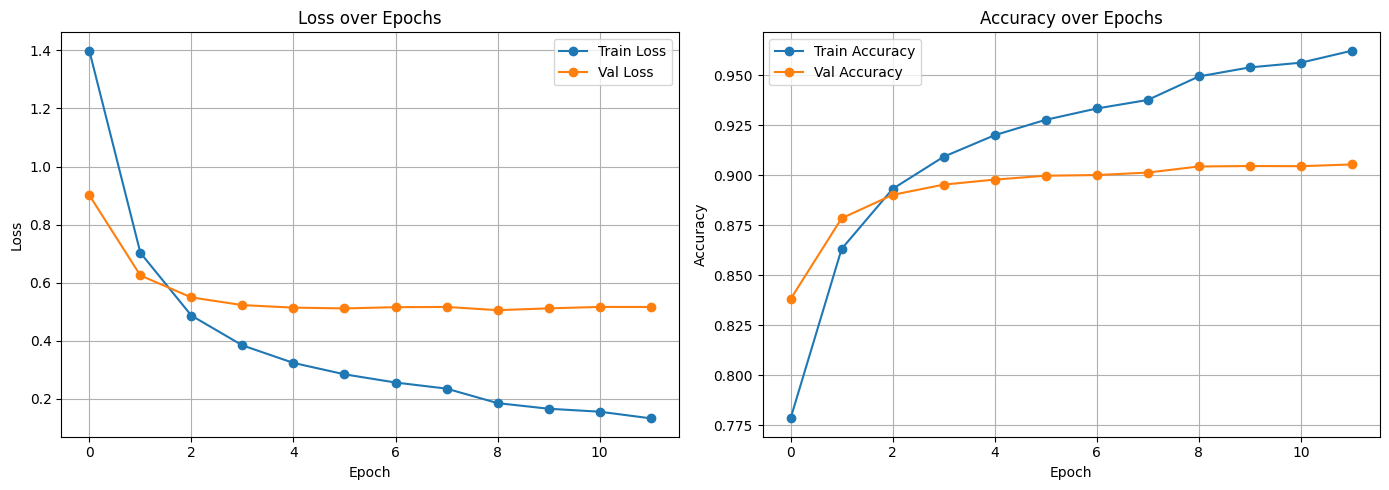

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────
axes[0].plot(history.history['loss'],     label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss',   marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# ── Accuracy ──────────────────────────────────────────────
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   marker='o')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [31]:
import pickle

# ── Save Models ───────────────────────────────────────────
model.save('seq2seq_model.keras')
encoder_model.save('encoder_model.keras')
decoder_model.save('decoder_model.keras')

# ── Save Vocabs ───────────────────────────────────────────
with open('eng_word2idx.pkl', 'wb') as f:
    pickle.dump(eng_word2idx, f)

with open('eng_idx2word.pkl', 'wb') as f:
    pickle.dump(eng_idx2word, f)

with open('deu_word2idx.pkl', 'wb') as f:
    pickle.dump(deu_word2idx, f)

with open('deu_idx2word.pkl', 'wb') as f:
    pickle.dump(deu_idx2word, f)

# ── Save Config ───────────────────────────────────────────
config = {
    'MAX_ENG_LEN'   : MAX_ENG_LEN,
    'MAX_DEU_LEN'   : MAX_DEU_LEN,
    'embedding_dim' : embedding_dim,
    'lstm_units'    : lstm_units,
    'en_vocab_size' : en_vocab_size,
    'de_vocab_size' : de_vocab_size,
}

with open('config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("All models and vocabs saved successfully!")

All models and vocabs saved successfully!


In [32]:
from tensorflow.keras.models import load_model
import pickle

encoder_model = load_model('encoder_model.keras')
decoder_model = load_model('decoder_model.keras')

with open('eng_word2idx.pkl', 'rb') as f:
    eng_word2idx = pickle.load(f)
with open('deu_idx2word.pkl', 'rb') as f:
    deu_idx2word = pickle.load(f)
with open('config.pkl', 'rb') as f:
    config = pickle.load(f)